# **Analysis of Aadhaar Enrollment Trends Across Regions and Age Groups in India (2025)**

**UIDAI Data Hackathon 2026**

This notebook presents an exploratory data analysis of Aadhaar enrollment data released by UIDAI.  
The analysis focuses on understanding **temporal trends**, **regional distribution**, and **age-wise enrollment patterns** for the year 2025.



## **1. Problem Statement**

Aadhaar enrollment is a cornerstone of India’s digital governance ecosystem, enabling access to welfare schemes, financial services, and identity verification.

Understanding **when**, **where**, and **which age groups** are enrolling helps UIDAI:
- Plan targeted enrollment drives
- Allocate enrollment infrastructure efficiently
- Identify regional and demographic gaps

This project analyzes Aadhaar enrollment data to extract meaningful insights that can support **data-driven decision-making**.


## **2. Dataset Description**

- **Dataset Name:** Aadhaar Enrollment Dataset  
- **Source:** Unique Identification Authority of India (UIDAI)  
- **Data Type:** Aggregated and anonymized enrollment records  
- **Time Period Covered:** March 2025 – December 2025  
- **Granularity:** District-level  

### **Files Used**
Due to large size, the dataset is provided in multiple parts:

- `api_data_aadhar_enrolment_0_500000.csv`
- `api_data_aadhar_enrolment_500000_1000000.csv`
- `api_data_aadhar_enrolment_1000000_1006029.csv`

All files represent **consecutive portions of the same dataset** and are merged for analysis.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## **3. Data Loading and Merging**

The individual CSV files are loaded using Pandas and concatenated into a single DataFrame to form a complete dataset for analysis.


In [2]:
df1 = pd.read_csv("/content/api_data_aadhar_enrolment_0_500000.csv")
df2 = pd.read_csv("/content/api_data_aadhar_enrolment_1000000_1006029.csv")
df3 = pd.read_csv("/content/api_data_aadhar_enrolment_500000_1000000.csv")

In [3]:
df = pd.concat([df1, df2, df3], ignore_index=True)
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21
...,...,...,...,...,...,...,...
1006024,31-12-2025,Telangana,Hyderabad,500045,4,5,1
1006025,31-12-2025,Telangana,Hyderabad,500057,0,2,0
1006026,31-12-2025,Telangana,Hyderabad,500061,4,2,0
1006027,31-12-2025,Telangana,Hyderabad,500062,1,4,0


## **4. Initial Data Exploration**

After merging the datasets, the structure and sample records are inspected to understand:
- Column names and data types
- Presence of missing values
- Overall size of the dataset


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB


In [5]:
df.describe()

,pincode,age_0_5,age_5_17,age_18_greater
count,1.006029e+06,1.006029e+06,1.006029e+06,1.006029e+06
mean,5.186415e+05,3.525709e+00,1.710074e+00,1.673441e-01
std,2.056360e+05,1.753851e+01,1.436963e+01,3.220525e+00
min,1.000000e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.636410e+05,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.174170e+05,2.000000e+00,0.000000e+00,0.000000e+00
75%,7.001040e+05,3.000000e+00,1.000000e+00,0.000000e+00
max,8.554560e+05,2.688000e+03,1.812000e+03,8.550000e+02


In [6]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [7]:
df.shape

(1006029, 7)

In [8]:
df.size

7042203

## **5. Feature Engineering**

To simplify analysis, a new feature called **total_enrolment** is created by summing enrollments across all age groups:
- Age 0–5
- Age 5–17
- Age 18 and above

Additionally, the date column is converted into a datetime format, and the **month** is extracted for time-based analysis.


In [9]:
df['total_enrolment'] = (
    df['age_0_5'] +
    df['age_5_17'] +
    df['age_18_greater']
)

In [10]:
df[['age_0_5','age_5_17','age_18_greater','total_enrolment']].head()

,age_0_5,age_5_17,age_18_greater,total_enrolment
0,11,61,37,109
1,14,33,39,86
2,29,82,12,123
3,62,29,15,106
4,14,16,21,51


In [11]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['month'] = df['date'].dt.month

In [12]:
df['date'].min(), df['date'].max(), df['month'].unique()

(Timestamp('2025-03-02 00:00:00'),
 Timestamp('2025-12-31 00:00:00'),
 array([ 3,  4,  5,  6,  7,  9, 10, 12, 11], dtype=int32))

## **6. Monthly Aadhaar Enrollment Trend (2025)**

Since the dataset contains records only for the year 2025, enrollment trends are analyzed on a **monthly basis** rather than year-wise.

This helps identify:
- Seasonal patterns
- Months with unusually high or low enrollment activity


In [13]:
monthly_trend = df.groupby('month')['total_enrolment'].sum().reset_index()
monthly_trend

,month,total_enrolment
0,3,16582
1,4,257438
2,5,183616
3,6,215734
4,7,616868
5,9,1475879
6,10,817920
7,11,1092007
8,12,759658


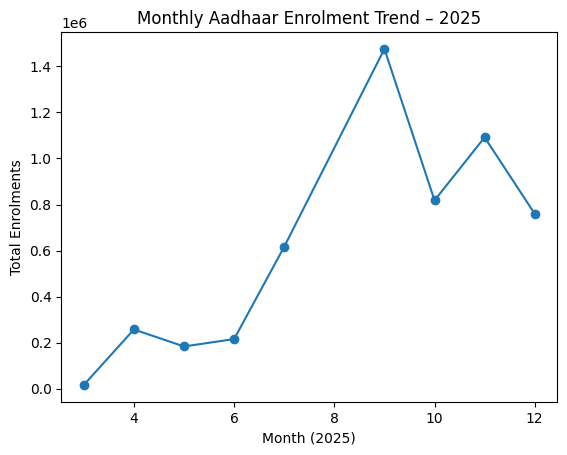

In [14]:
plt.figure()
plt.plot(monthly_trend['month'], monthly_trend['total_enrolment'], marker='o')
plt.xlabel('Month (2025)')
plt.ylabel('Total Enrolments')
plt.title('Monthly Aadhaar Enrolment Trend – 2025')
plt.show()

## **7. State-wise Enrollment Analysis**

To understand regional variation, total Aadhaar enrollments are aggregated at the **state level**.

The top 10 states with the highest enrollments are visualized to highlight major enrollment contributors in 2025.


In [15]:
state_enrolment = (
    df.groupby('state')['total_enrolment']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
state_enrolment

,state,total_enrolment
0,Uttar Pradesh,1018629
1,Bihar,609585
2,Madhya Pradesh,493970
3,West Bengal,375297
4,Maharashtra,369139
5,Rajasthan,348458
6,Gujarat,280549
7,Assam,230197
8,Karnataka,223235
9,Tamil Nadu,220789


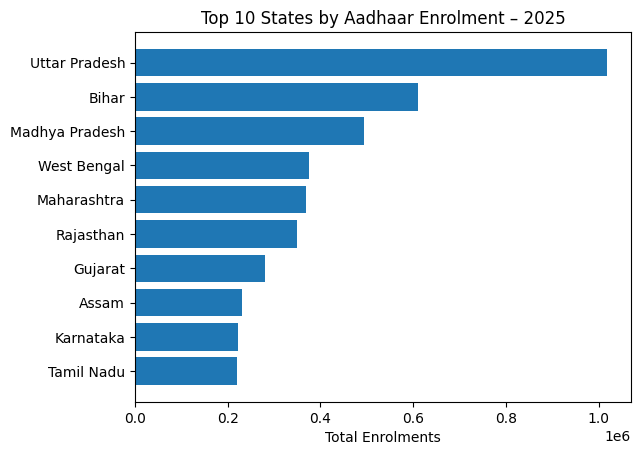

In [16]:
plt.figure()
plt.barh(state_enrolment['state'], state_enrolment['total_enrolment'])
plt.xlabel('Total Enrolments')
plt.title('Top 10 States by Aadhaar Enrolment – 2025')
plt.gca().invert_yaxis()
plt.show()

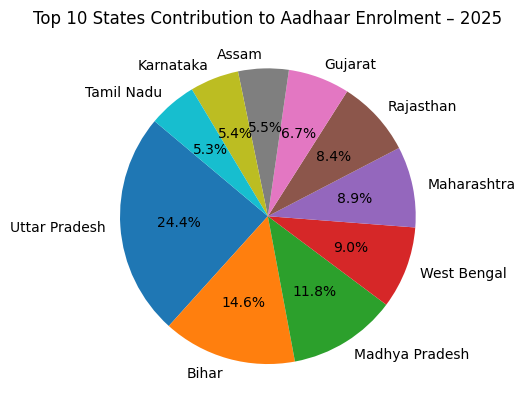

In [17]:
plt.figure()
plt.pie(
    state_enrolment['total_enrolment'],
    labels=state_enrolment['state'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Top 10 States Contribution to Aadhaar Enrolment – 2025')
plt.show()

## **8. Age-wise Enrollment Distribution**

Enrollment data is categorized into three age groups:
- Children (0–5 years)
- Adolescents (5–17 years)
- Adults (18+ years)

This analysis helps assess which demographic groups are contributing most to Aadhaar enrollment during 2025.


In [18]:
age_totals = {
    'Age 0–5': df['age_0_5'].sum(),
    'Age 5–17': df['age_5_17'].sum(),
    'Age 18+': df['age_18_greater'].sum()
}

age_totals

{'Age 0–5': np.int64(3546965),
 'Age 5–17': np.int64(1720384),
 'Age 18+': np.int64(168353)}

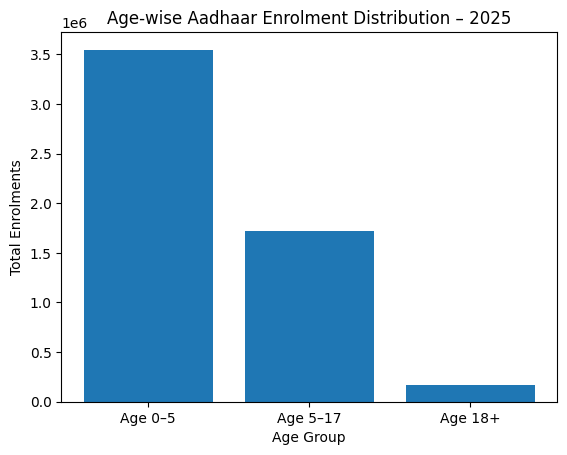

In [19]:
plt.figure()
plt.bar(age_totals.keys(), age_totals.values())
plt.xlabel('Age Group')
plt.ylabel('Total Enrolments')
plt.title('Age-wise Aadhaar Enrolment Distribution – 2025')
plt.show()

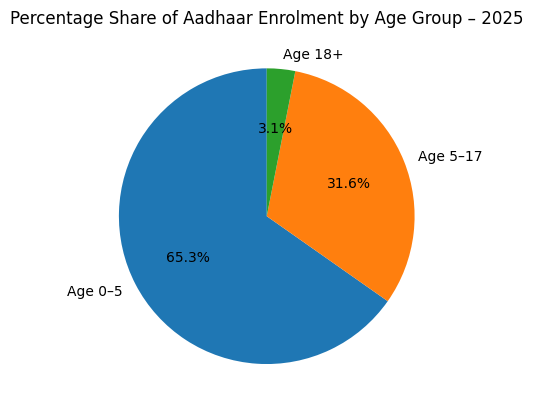

In [20]:
plt.figure()
plt.pie(
    age_totals.values(),
    labels=age_totals.keys(),
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Percentage Share of Aadhaar Enrolment by Age Group – 2025')
plt.show()

## **9. District-level Enrollment Hotspots**

To identify localized enrollment intensity, district-wise enrollments are aggregated.

The top districts highlight regions with exceptionally high Aadhaar enrollment activity, which may indicate:
- Urban population concentration
- Active enrollment drives
- Higher administrative efficiency


In [21]:
top_districts = (
    df.groupby(['state','district'])['total_enrolment']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_districts

,state,district,total_enrolment
0,Maharashtra,Thane,43688
1,Bihar,Sitamarhi,42232
2,Uttar Pradesh,Bahraich,39338
3,West Bengal,Murshidabad,35911
4,West Bengal,South 24 Parganas,33540
5,Maharashtra,Pune,31763
6,Rajasthan,Jaipur,31146
7,Karnataka,Bengaluru,30980
8,Uttar Pradesh,Sitapur,30854
9,Bihar,West Champaran,30438


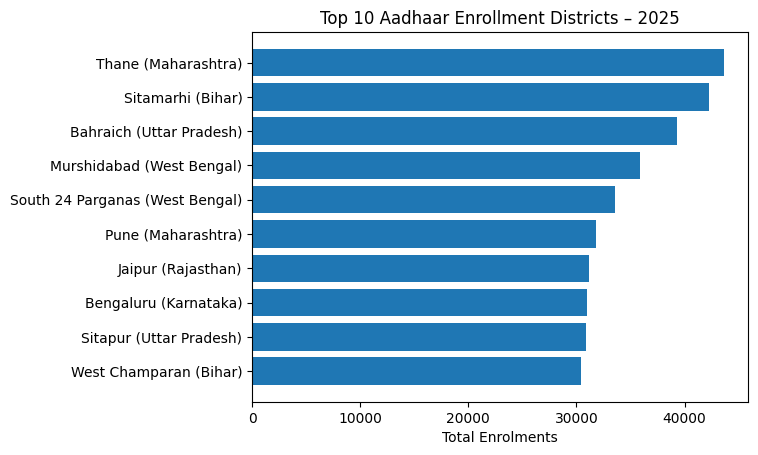

In [22]:
plt.figure()
plt.barh(
    top_districts['district'] + " (" + top_districts['state'] + ")",
    top_districts['total_enrolment']
)
plt.xlabel('Total Enrolments')
plt.title('Top 10 Aadhaar Enrollment Districts – 2025')
plt.gca().invert_yaxis()
plt.show()

## **10. Monthly Enrollment Volume**

This bar chart complements the trend analysis by showing the absolute number of enrollments recorded each month in 2025.


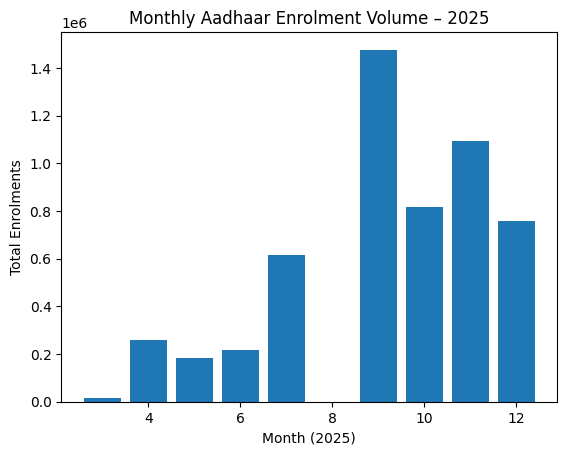

In [23]:
plt.figure()
plt.bar(monthly_trend['month'], monthly_trend['total_enrolment'])
plt.xlabel('Month (2025)')
plt.ylabel('Total Enrolments')
plt.title('Monthly Aadhaar Enrolment Volume – 2025')
plt.show()

## **11. District Count per State (Hotspot Density)**

This visualization shows the distribution of high-enrolment (hotspot) districts across states, based on districts that appear among the top Aadhaar enrolment contributors in 2025. Instead of measuring volume, this analysis focuses on concentration and spread of enrolment activity.

States with a higher count of hotspot districts indicate a more distributed enrolment demand, suggesting consistent administrative outreach and higher population coverage across multiple districts. In contrast, states with fewer hotspot districts reflect localized enrolment pressure, where a small number of districts account for a large share of enrolments.

**This insight is important for UIDAI because it helps identify:**
*   States requiring district-level infrastructure expansion
*   Regions where enrolment demand is clustered vs evenly spread
*   Opportunities for targeted resource allocation and operational planning

Overall, district hotspot density complements total enrolment analysis by highlighting structural patterns in regional enrolment behavior, not just raw numbers.

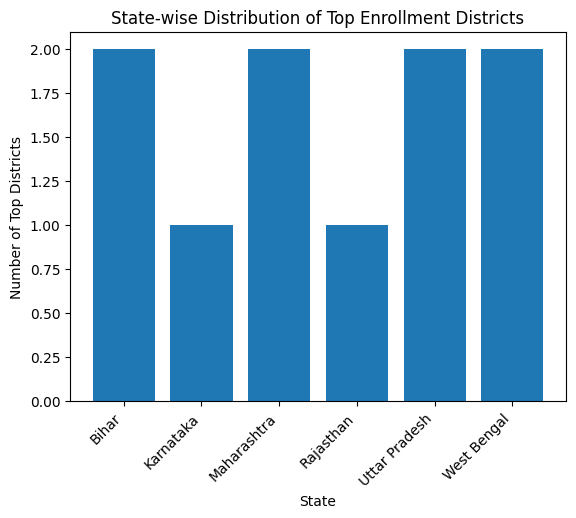

In [24]:
district_count = (
    top_districts.groupby('state')['district']
    .count()
    .reset_index(name='Top_District_Count')
)

plt.figure()
plt.bar(district_count['state'], district_count['Top_District_Count'])
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Top Districts')
plt.title('State-wise Distribution of Top Enrollment Districts')
plt.show()

## **12. Key Insights**

- Aadhaar enrollments in 2025 show **clear monthly variation**, indicating time-dependent enrollment behavior.
- The **0–5 age group** accounts for the highest enrollments, reflecting strong early-life Aadhaar registration.
- A limited number of states contribute a significant share of total enrollments, suggesting regional concentration.
- Certain districts emerge as enrollment hotspots, which can guide infrastructure planning and outreach strategies.


## **13. Conclusion and Future Scope**

This analysis provides a clear snapshot of Aadhaar enrollment patterns in India for the year 2025.


## **14. Future Enhancements**
- Extend analysis across multiple years to study long-term trends
- Combine enrollment data with population statistics for penetration analysis
- Apply anomaly detection to identify unusual enrollment spikes
- Develop dashboards for real-time monitoring

Such insights can support UIDAI in enhancing coverage, efficiency, and inclusivity.